In [1]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

performance = pd.read_csv(
    "../data/processed/scheme_performance_cleaned.csv"
)

benchmark = pd.read_csv(
    "../data/raw/benchmark_indices.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

In [2]:
nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = nav.groupby(
    "amfi_code"
)["nav"].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


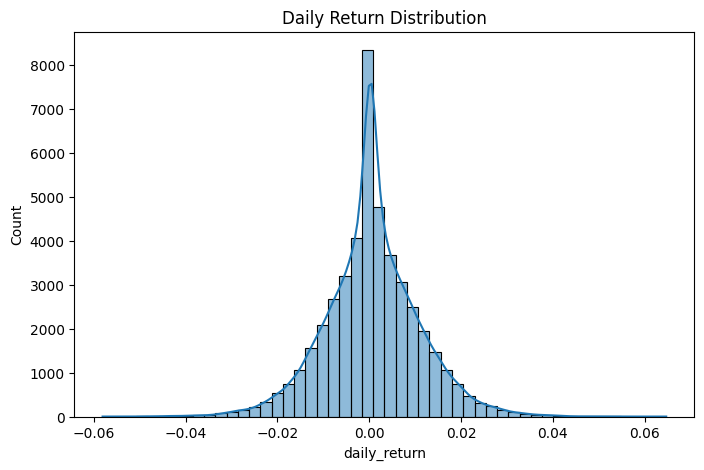

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(

nav["daily_return"].dropna(),

bins=50,

kde=True

)

plt.title("Daily Return Distribution")

plt.show()

In [5]:
cagr_list = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    start_nav = group.iloc[0]["nav"]

    end_nav = group.iloc[-1]["nav"]

    years = (
        group["date"].max() -
        group["date"].min()
    ).days / 365

    cagr = (
        (end_nav/start_nav)
        **(1/years)
    ) - 1

    cagr_list.append(
        [code,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_list,

    columns=["amfi_code","CAGR"]
)

cagr_df.head()

,amfi_code,CAGR
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [6]:
rf = 0.065

sharpe = []

for code, group in nav.groupby("amfi_code"):

    ret = group["daily_return"].dropna()

    sr = (

        (ret.mean()-rf/252)

        /

        ret.std()

    ) * np.sqrt(252)

    sharpe.append([code,sr])

sharpe_df = pd.DataFrame(

    sharpe,

    columns=["amfi_code","Sharpe"]

)

In [7]:
sortino=[]

for code, group in nav.groupby("amfi_code"):

    ret=group["daily_return"].dropna()

    downside=ret[ret<0]

    ratio=(

        ret.mean()

        /

        downside.std()

    )*np.sqrt(252)

    sortino.append([code,ratio])

sortino_df=pd.DataFrame(

sortino,

columns=["amfi_code","Sortino"]

)

In [8]:
drawdowns=[]

for code,group in nav.groupby("amfi_code"):

    group=group.sort_values("date")

    running_max=group["nav"].cummax()

    dd=(

        group["nav"]

        /

        running_max

    )-1

    drawdowns.append(

        [code,dd.min()]

    )

dd_df=pd.DataFrame(

drawdowns,

columns=["amfi_code","Max_Drawdown"]

)

In [9]:
scorecard = (

performance

.merge(

cagr_df,

on="amfi_code"

)

.merge(

sharpe_df,

on="amfi_code"

)

.merge(

dd_df,

on="amfi_code"

)

)

scorecard.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,CAGR,Sharpe,Max_Drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,1.29,14.0,-21.70,14288,1.54,4,Moderate,0.257849,1.208267,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,1.29,14.0,-24.43,1231,0.66,3,Moderate,0.215080,0.953279,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,1.35,25.0,-13.35,19259,1.43,5,Very High,0.323981,0.945308,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,1.67,25.0,-24.78,36061,0.72,4,Very High,0.020531,-0.057187,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,2.11,4.0,-2.30,24101,0.77,5,Low,0.058853,-0.226575,-0.043287


In [10]:
scorecard.to_csv(

"../reports/fund_scorecard.csv",

index=False

)

In [11]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [12]:
benchmark = benchmark.sort_values("date")

benchmark["benchmark_return"] = (
    benchmark["close_value"]
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
5750,2022-01-03,CRISIL_LIQUID,2281.51,-0.869574
2300,2022-01-03,NIFTY_MIDCAP150,9721.79,3.261121
6900,2022-01-03,CRISIL_GILT,1451.06,-0.850741
1150,2022-01-03,NIFTY100,17778.24,11.251899


In [13]:
merged = nav.merge(

benchmark[

["date","benchmark_return"]

],

on="date",

how="inner"

)

merged.head()

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-03,520.4608,NaN,-0.869574
2,100016,2022-01-03,520.4608,NaN,3.261121
3,100016,2022-01-03,520.4608,NaN,-0.850741
4,100016,2022-01-03,520.4608,NaN,11.251899


In [14]:
from scipy.stats import linregress

alpha_beta=[]

for code, group in merged.groupby("amfi_code"):

    x = group["benchmark_return"].dropna()

    y = group["daily_return"].dropna()

    n = min(len(x),len(y))

    x=x.iloc[:n]

    y=y.iloc[:n]

    beta, alpha, r, p, se = linregress(x,y)

    alpha = alpha * 252

    alpha_beta.append(

        [code,alpha,beta]

    )

alpha_beta_df = pd.DataFrame(

alpha_beta,

columns=[

"amfi_code",

"alpha",

"beta"

]

)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.036477,-0.000001
1,100025,0.045279,-0.000004
2,100033,0.276279,-0.000007
3,101206,0.213476,0.000002
4,101207,0.118080,-0.000019


In [15]:
alpha_beta_df.to_csv(

"../reports/alpha_beta.csv",

index=False

)

In [16]:
top5 = performance.sort_values(

"aum_crore",

ascending=False

).head(5)

top5_codes = top5["amfi_code"].tolist()

top5_codes

[148568, 120842, 118634, 149322, 102886]

In [18]:
top_nav = nav[
    nav["amfi_code"].isin(top5_codes)
]

top_nav.head()

,amfi_code,date,nav,daily_return
8050,102886,2022-01-03,119.2905,NaN
8051,102886,2022-01-04,120.6402,0.011314
8052,102886,2022-01-05,121.4580,0.006779
8053,102886,2022-01-06,125.2386,0.031127
8054,102886,2022-01-07,124.1321,-0.008835


In [19]:
import plotly.express as px

fig = px.line(
    top_nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Top 5 Funds vs Benchmark"
)

fig.show()

In [20]:
fig.write_image("../reports/benchmark_comparison.png")

In [21]:
tracking=[]

for code,group in merged.groupby(

"amfi_code"

):

    diff=(

        group["daily_return"]

        -

        group["benchmark_return"]

    ).dropna()

    te=diff.std()*np.sqrt(252)

    tracking.append(

        [code,te]

    )

tracking_df=pd.DataFrame(

tracking,

columns=[

"amfi_code",

"tracking_error"

]

)

tracking_df.head()

,amfi_code,tracking_error
0,100016,80.965279
1,100025,80.965156
2,100033,80.964124
3,101206,80.964144
4,101207,80.965687
